In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, GroupKFold, LeaveOneGroupOut
import matplotlib.pyplot as plt

np.random.seed(0)
n_subjects = 6
n_trials_per_subject = 10
n_total = n_subjects * n_trials_per_subject

subject_ids = np.repeat(np.arange(n_subjects), n_trials_per_subject)

# Her subject'in KENDİNE ÖZGÜ bir "baseline offset"i var (gerçek EEG'de bireysel farklılıklar gibi)
subject_offset = np.random.randn(n_subjects) * 2
features = np.random.randn(n_total, 5) + subject_offset[subject_ids].reshape(-1,1)
labels = (features[:,0] + subject_offset[subject_ids]*0.5 > 0).astype(int)

print("Toplam örnek sayısı:", n_total, "| Subject sayısı:", n_subjects)

Toplam örnek sayısı: 60 | Subject sayısı: 6


Standart K-fold: Subject x Fold dağılımı
 col_0  0  1  2  3  4
row_0               
0      2  1  2  2  3
1      2  1  4  2  1
2      3  1  2  2  2
3      2  3  1  2  2
4      1  4  0  3  2
5      2  2  3  1  2


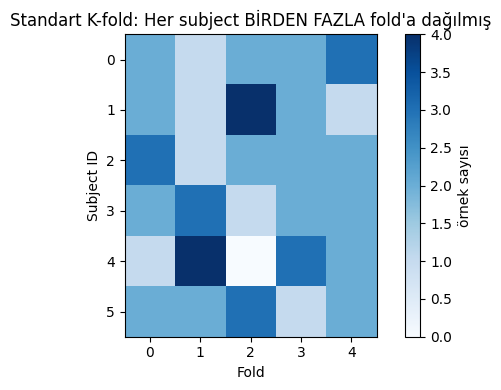

In [2]:
kf = KFold(n_splits=5, shuffle=True, random_state=0)
fold_assignment_standard = np.zeros(n_total, dtype=int)
for fold_idx, (_, test_idx) in enumerate(kf.split(features)):
    fold_assignment_standard[test_idx] = fold_idx

table = pd.crosstab(subject_ids, fold_assignment_standard)
print("Standart K-fold: Subject x Fold dağılımı\n", table)

plt.figure(figsize=(6,4))
plt.imshow(table.values, cmap='Blues')
plt.xlabel("Fold"); plt.ylabel("Subject ID")
plt.title("Standart K-fold: Her subject BİRDEN FAZLA fold'a dağılmış")
plt.colorbar(label="örnek sayısı")
plt.tight_layout(); plt.show()

GroupKFold: Subject x Fold dağılımı
 col_0   0   1   2   3   4
row_0                    
0      10   0   0   0   0
1       0   0   0   0  10
2       0   0   0  10   0
3       0   0  10   0   0
4       0  10   0   0   0
5      10   0   0   0   0


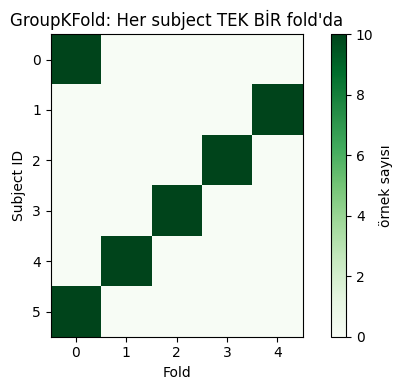

In [3]:
gkf = GroupKFold(n_splits=5)
fold_assignment_group = np.zeros(n_total, dtype=int)
for fold_idx, (_, test_idx) in enumerate(gkf.split(features, labels, groups=subject_ids)):
    fold_assignment_group[test_idx] = fold_idx

table_group = pd.crosstab(subject_ids, fold_assignment_group)
print("GroupKFold: Subject x Fold dağılımı\n", table_group)

plt.figure(figsize=(6,4))
plt.imshow(table_group.values, cmap='Greens')
plt.xlabel("Fold"); plt.ylabel("Subject ID")
plt.title("GroupKFold: Her subject TEK BİR fold'da")
plt.colorbar(label="örnek sayısı")
plt.tight_layout(); plt.show()

In [4]:
logo = LeaveOneGroupOut()
print("LOSO fold sayısı (= subject sayısı):", logo.get_n_splits(groups=subject_ids))
for fold_idx, (train_idx, test_idx) in enumerate(logo.split(features, labels, groups=subject_ids)):
    print(f"Fold {fold_idx}: test subject = {subject_ids[test_idx][0]}, test örnek sayısı = {len(test_idx)}")

LOSO fold sayısı (= subject sayısı): 6
Fold 0: test subject = 0, test örnek sayısı = 10
Fold 1: test subject = 1, test örnek sayısı = 10
Fold 2: test subject = 2, test örnek sayısı = 10
Fold 3: test subject = 3, test örnek sayısı = 10
Fold 4: test subject = 4, test örnek sayısı = 10
Fold 5: test subject = 5, test örnek sayısı = 10


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(n_estimators=100, random_state=0)

acc_standard = cross_val_score(model, features, labels, cv=kf).mean()
acc_group = cross_val_score(model, features, labels, cv=gkf, groups=subject_ids).mean()
acc_loso = cross_val_score(model, features, labels, cv=logo, groups=subject_ids).mean()

print(f"Standart K-fold accuracy (subject leakage riskli): {acc_standard:.3f}")
print(f"GroupKFold accuracy (subject-independent):          {acc_group:.3f}")
print(f"LOSO accuracy (subject-independent):                 {acc_loso:.3f}")

Standart K-fold accuracy (subject leakage riskli): 0.967
GroupKFold accuracy (subject-independent):          0.960
LOSO accuracy (subject-independent):                 0.967


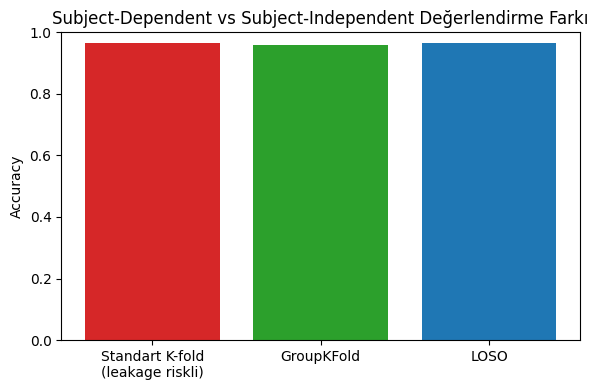

In [6]:
plt.figure(figsize=(6,4))
plt.bar(["Standart K-fold\n(leakage riskli)", "GroupKFold", "LOSO"],
        [acc_standard, acc_group, acc_loso], color=['tab:red','tab:green','tab:blue'])
plt.ylabel("Accuracy")
plt.title("Subject-Dependent vs Subject-Independent Değerlendirme Farkı")
plt.ylim(0,1)
plt.tight_layout(); plt.show()